Make the 2D redshift slice plots

In [256]:
import os
import sys
import glob
import numpy as np
from tqdm import trange
from astropy.io import fits
from astropy.table import Table, vstack
from astropy.convolution import convolve, Gaussian1DKernel
import astropy.units as u
import astropy.coordinates as coord
import matplotlib
import matplotlib.pyplot as plt
from astropy.table import Column
from tqdm import trange
import pandas as pd
import fitsio
from astropy.table import Table, vstack
from astropy import units as u
from astropy.coordinates import SkyCoord
from easyquery import Query, QueryMaker
from scipy.stats import binomtest
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap, BoundaryNorm
import h5py
from astropy.cosmology import Planck18


import matplotlib as mpl

mpl.rcParams.update({
    # --- Fonts (your existing sizes + cmr10 serif from new style) ---
    'font.family':                 'serif',
    'font.serif':                  'cmr10',
    'font.size':                   11,
    'mathtext.fontset':            'cm',
    'axes.unicode_minus':          False,
    'axes.formatter.use_mathtext': True,
    'axes.labelsize':              12,
    'axes.titlesize':              12,
    'xtick.labelsize':             10,
    'ytick.labelsize':             10,
    'legend.fontsize':             11,

    # --- Axes ---
    'axes.linewidth':              1.0,
    'axes.xmargin':                0.05,

    # --- X ticks: in, all sides, minor ticks on ---
    'xtick.direction':             'in',
    'xtick.top':                   True,
    'xtick.minor.visible':         True,
    'xtick.major.top':             True,
    'xtick.minor.top':             True,
    'xtick.major.size':            3.5,
    'xtick.minor.size':            2.0,
    'xtick.major.width':           1.0,
    'xtick.minor.width':           0.8,
    'xtick.major.pad':             4,
    'xtick.minor.pad':             4,

    # --- Y ticks: in, all sides, minor ticks on ---
    'ytick.direction':             'in',
    'ytick.right':                 True,
    'ytick.minor.visible':         True,
    'ytick.major.right':           True,
    'ytick.minor.right':           True,
    'ytick.major.size':            3.5,
    'ytick.minor.size':            2.0,
    'ytick.major.width':           1.0,
    'ytick.minor.width':           0.8,
    'ytick.major.pad':             4,
    'ytick.minor.pad':             4,

    # --- Legend ---
    'legend.frameon':              False,
    'legend.edgecolor':            'k',
    'legend.framealpha':           0,

    # --- Figure / savefig / misc ---
    'figure.facecolor':            'w',
    'image.aspect':                'auto',
    'image.cmap':                  'magma',
    'savefig.format':              'pdf',
    'savefig.bbox':                'tight',
    'savefig.dpi':                 300,
    'savefig.transparent':         False,
    'errorbar.capsize':            0,
    'lines.markersize':            5,
    'hist.bins':                   'auto',
})


%load_ext autoreload
%autoreload 2

MARGIN_LABEL  = 0.9   # edge with axis label + tick labels
MARGIN_TICKS  = 0.45  # edge with only tick labels (no axis label)
MARGIN_PAD    = 0.2   # edge with nothing
MARGIN_SHARED = 0.1   # gap between panels sharing an axis
MARGIN_SPLIT  = 0.7   # gap between panels with independent axes
MARGIN_CBAR   = 1.1   # edge with a colorbar

rootdir = '/global/u1/v/virajvm/'
sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code'))

from desi_lowz_funcs import make_subplots, match_c_to_catalog, print_radecs
from desi_lowz_funcs import calc_normalized_dist
from desi_lowz_funcs import find_objects_nearby
from construct_dwarf_galaxy_catalogs import process_sga_matches

from desi_lowz_funcs import make_subplots, match_c_to_catalog, print_radecs
from desi_lowz_funcs import calc_normalized_dist
from desi_lowz_funcs import find_objects_nearby
# from construct_dwarf_galaxy_catalogs import process_sga_matches

# from consolidate_photometry import get_fastspec_fit_catalog_V2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Make a slice plot focusing on the patch where DESI is really complete and do something there!

In [147]:

# Path to the catalog
filename = "/pscratch/sd/v/virajvm/desi_dwarf_catalogs/dr1/v1.0/desi_dr1_dwarf_catalog.fits"

# Option 1: load the MAIN extension directly as an Astropy Table
main = Table.read(filename, hdu="MAIN")

# Option 2: load the SPEC_DERIVED extension
fastspec = Table.read(filename, hdu="SPEC_DERIVED")


In [148]:
len(main)

469715

In [149]:
tot_cat = main.copy()

tot_cat = tot_cat[(tot_cat["DWARF_MASKBIT"] == 0) & (tot_cat["DWARF_PRIMARY"] == 1)]

In [150]:
len(tot_cat)

436291

In [151]:
tot_cat["LOG_MSTAR_M24"].max()

np.float64(9.24999713897705)

## Make the slice plot!!

In [18]:

##make the DESI slice

dec_low = 0 - 5
dec_high = 0 + 5

slice_mask = (tot_cat["RA"] < 230) & (tot_cat["RA"] > 130) & (tot_cat["DEC"] > dec_low) & (tot_cat["DEC"] < dec_high) #& (tot_cat["Z"] < 0.2) 

tot_cat_slice = tot_cat[slice_mask]

##read in GAMA catalog
gama_cat = Table.read("/pscratch/sd/v/virajvm/catalog/gama_dwarf_cat.fits")

slice_mask_gama = (gama_cat["RAcen"] < 230) & (gama_cat["RAcen"] > 130) & (gama_cat["Deccen"] > dec_low) & (gama_cat["Deccen"] < dec_high) 

tot_cat_slice_gama = gama_cat[ slice_mask_gama ]

# gama_g12_mask = (tot_cat["RA"] < 186) & (tot_cat["RA"] > 174) & (tot_cat["DEC"] > -3) & (tot_cat["DEC"] < 2) & (tot_cat["Z"] < 0.2) & (tot_cat["MAG_R"] < 19.8)
# gama_g09_mask = (tot_cat["RA"] < 141) & (tot_cat["RA"] > 129) & (tot_cat["DEC"] > -2) & (tot_cat["DEC"] < 3) & (tot_cat["Z"] < 0.2) & (tot_cat["MAG_R"] < 19.8)
# gama_g15_mask = (tot_cat["RA"] < 223.5) & (tot_cat["RA"] > 211.5) & (tot_cat["DEC"] > -2) & (tot_cat["DEC"] < 3) & (tot_cat["Z"] < 0.2)   & (tot_cat["MAG_R"] < 19.8)
# tot_cat_slice_gama = tot_cat[  gama_g12_mask | gama_g15_mask | gama_g09_mask ]

tot_cat_slice_gama.rename_column("RAcen","RA")
tot_cat_slice_gama.rename_column("Deccen","DEC")

tot_cat_slice_gama["comov_dist"] = Planck18.comoving_distance(tot_cat_slice_gama["Z"]).data
###read in SDSS/NSA catalog

sdss_nsa_cat = Table.read("/pscratch/sd/v/virajvm/catalog/nsa_dwarf_catalog.fits")

slice_mask_sdss = (sdss_nsa_cat["RA"] < 230) & (sdss_nsa_cat["RA"] > 130) & (sdss_nsa_cat["DEC"] > dec_low) & (sdss_nsa_cat["DEC"] < dec_high) 

tot_cat_slice_sdss = sdss_nsa_cat[slice_mask_sdss ]

tot_cat_slice_sdss["comov_dist"] = Planck18.comoving_distance(tot_cat_slice_sdss["Z"]).data


(100.0, 230.0)

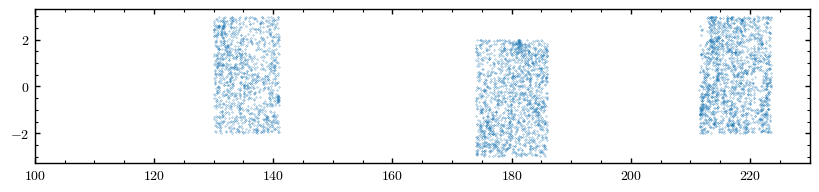

In [19]:
plt.figure(figsize = (10,2))
plt.scatter(tot_cat_slice_gama["RA"], tot_cat_slice_gama["DEC"],s=0.05)
plt.xlim([100,230])


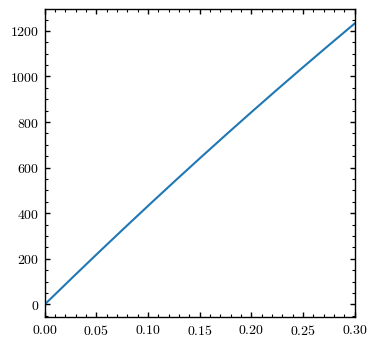

In [20]:
zmax = 0.3

zgrid = np.linspace(0.001,zmax,1000)

cmov_dist = Planck18.comoving_distance(zgrid)

from scipy.interpolate import UnivariateSpline

spl_z = UnivariateSpline( cmov_dist, zgrid, s=0.)

plt.figure(figsize = (4,4))
plt.plot(zgrid, cmov_dist)
plt.xlim([0,zmax])
plt.show()

In [21]:
from astropy.table import Table

# saga_gals = Table.read('https://sagasurvey.org/data/saga-dr3-tableC2.txt', format='ascii.mrt')
saga_gals = Table.read("/pscratch/sd/v/virajvm/catalog/saga_dr3_dwarf_cat.fits")
print(len(saga_gals))

saga_gals.rename_columns(["RAdeg", "DEdeg","z"], ["RA","DEC","Z"])

9904


In [22]:
##measure stellar mass in same way as we are measuring the other stellar masses

saga_slice_mask = (saga_gals["RA"] < 230) & (saga_gals["RA"] > 130) & (saga_gals["DEC"] < 5) & (saga_gals["DEC"] > -5) & (saga_gals["Z"] >0) & (saga_gals["Z"] < 0.3)

saga_gals_slice = saga_gals[saga_slice_mask]

print(len(saga_gals_slice))

saga_gals_slice["comov_dist"] = Planck18.comoving_distance(saga_gals_slice["Z"]).data


1690


In [37]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(6.875, 0.35))
fig.text(0.5, 0.5, "Dwarf Galaxies in DESI DR1",
         ha="center", va="center",
         fontsize=13)   # use the same fontsize you used for "Prior to DESI"
plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/top_header.pdf", bbox_inches="tight", transparent=True)
plt.close(fig)

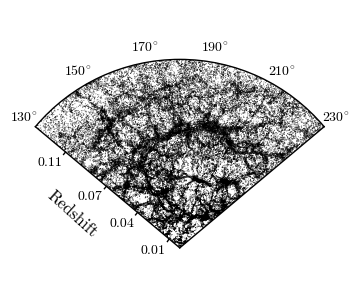

In [24]:
ra_ticks_vals = np.array([130,150, 170, 190, 210, 230])
ra_min = 130
ra_max = 230
pad_val =-15

fig, ax = plt.subplots(1,1,figsize = (3.75,3.75),subplot_kw={'projection': 'polar'})

### ALL GALAXIES IN NED-LVS
ra_radians = np.deg2rad(tot_cat_slice["RA"])
ax.scatter(ra_radians, tot_cat_slice["LUMI_DIST_MPC"], color = "k", alpha=0.6,s=0.5,
           rasterized=True, linewidths=0, edgecolors="none")

# Add labels and a colorbar
ax.set_theta_zero_location("S")  # Optional: sets 0° at the bottom (South)
ax.set_theta_direction(-1)       # Optional: clockwise direction for RA
# Set title and labels
ax.set_thetamin(ra_min)   # Min angle in degrees (start of the slice)
ax.set_thetamax(ra_max)
ax.set_rlim(0,600)

ax.set_rticks([ 44.20505558, 175.56757391, 305.02911976, 474.64670145])

ax.set_yticklabels([r"$0.01$","0.04","0.07","0.11"])

# Add the label using ax.text()
ax.text(np.deg2rad(108),        # angle in radians
        ax.get_rmax() * 0.6,   # just outside the outermost circle
        "Redshift",
        rotation=-42,
        ha='center',
        va='center',
       fontsize = 12)

ax.grid(ls = ":", color = "lightgrey",alpha = 0.5)

rtick_vals = [44.20505558, 175.56757391, 305.02911976, 474.64670145]
tick_len = 10  # in data units (radius units), tweak to taste

for theta_deg, direction in [(ra_min, -1)]:
    theta = np.deg2rad(theta_deg)
    for r in rtick_vals:
        dtheta = direction * tick_len / r
        ax.plot([theta, theta + dtheta], [r, r],
                color='k', lw=1, clip_on=False)

ra_ticks = np.deg2rad(ra_ticks_vals)
ax.set_xticks(ra_ticks)
ax.set_xticklabels([fr'${int(r)}\!^\circ$' for r in ra_ticks_vals])

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/desi_slice_plot.pdf",dpi=300)

plt.show()


In [25]:
2.5*2.75

6.875

In [26]:
Planck18.comoving_distance([0.01,0.04,0.07,0.11]).value

array([ 44.20505558, 175.56757391, 305.02911976, 474.64670145])

In [27]:
import cmasher as cmr
from matplotlib.lines import Line2D

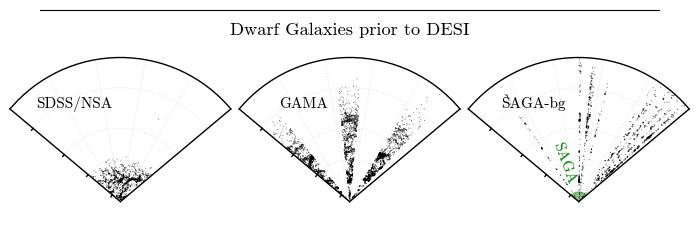

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(2.5*2.75, 2.5),
                         subplot_kw={'projection': 'polar'},
                         constrained_layout=True)

fig.suptitle("Dwarf Galaxies prior to DESI",y=0.93)
            # bbox=dict(boxstyle='round,pad=0.4',
            #            facecolor='white', edgecolor='k', lw=0.8))

line = Line2D([0.05, 0.95], [1.05-0.07, 1.05-0.07],
              color='k', lw=0.8,
              transform=fig.transFigure, figure=fig)
fig.add_artist(line)

rmax_val = 450
marker_size = 0.5

ra_radians = np.deg2rad(tot_cat_slice_sdss["RA"])
axes[0].scatter(ra_radians, tot_cat_slice_sdss["comov_dist"], color = "k", alpha=0.6,s=marker_size,
                rasterized=True, linewidths=0, edgecolors="none")

axes[0].text(np.deg2rad(155),        # angle in radians
        rmax_val,   # just outside the outermost circle
        "SDSS/NSA",
        color = "k",
        rotation=0,
        ha='center',
        va='center')

######

ra_radians = np.deg2rad(tot_cat_slice_gama["RA"])

axes[1].scatter(ra_radians, tot_cat_slice_gama["comov_dist"], color = "k", alpha=0.6,s=marker_size,
                rasterized=True, linewidths=0, edgecolors="none")

axes[1].text(np.deg2rad(155),        # angle in radians
        rmax_val,   # just outside the outermost circle
        "GAMA",
        color = "k",
        rotation=0,
        ha='center',
        va='center')

#####

ra_radians = np.deg2rad(saga_gals_slice["RA"])
axes[2].scatter(ra_radians, saga_gals_slice["comov_dist"], color = "k", alpha=0.6,s=marker_size,
                rasterized=True, linewidths=0, edgecolors="none")


# Parameters
r_max_shade = 40  # Up to what radius to shade
n_points = 500     # Resolution of the fill
theta1 = np.deg2rad(ra_min)
theta2 = np.deg2rad(ra_max)
theta = np.linspace(theta1, theta2, n_points)

# Create a filled sector
r_inner = np.zeros_like(theta)
r_outer = np.full_like(theta, r_max_shade)

# Fill from center to outer radius
axes[2].fill(np.concatenate([theta, theta[::-1]]),
        np.concatenate([r_inner, r_outer[::-1]]),
        color='green', alpha=0.5, zorder=0)

axes[2].text(np.deg2rad(160),        # angle in radians
        175,   # just outside the outermost circle
        "SAGA",
        color = "green",
        alpha = 1,
        rotation=-70,
        ha='center',
        va='center')


axes[2].text(np.deg2rad(155),        # angle in radians
        rmax_val,   # just outside the outermost circle
        "SAGA-bg",
        color = "k",
        rotation=0,
        ha='center',
        va='center')

for axi in axes:
    axi.set_theta_zero_location("S")  # Optional: sets 0° at the bottom (South)
    axi.set_theta_direction(-1)       # Optional: clockwise direction for RA
    # Set title and labels
    # ax.set_title('Galaxy Distribution by Redshift and RA')
    axi.set_thetamin(ra_min)   # Min angle in degrees (start of the slice)
    axi.set_thetamax(ra_max)
    axi.set_rlim(0,600)

    axi.tick_params(axis='x', pad=0)  # negative moves labels closer to the plot

    axi.set_rticks([ 44.20505558, 175.56757391, 305.02911976, 474.64670145])
    
    axi.set_yticklabels([r"","","",""])

    ra_ticks = np.deg2rad(ra_ticks_vals)
    
    axi.set_xticks(ra_ticks)
    axi.set_xticklabels([fr'' for r in ra_ticks_vals])
    
    axi.grid(ls = ":", color = "lightgrey",alpha = 0.5)
    
    rtick_vals = [44.20505558, 175.56757391, 305.02911976, 474.64670145]
    tick_len = 10  # in data units (radius units), tweak to taste
    
    for theta_deg, direction in [(ra_min, -1)]:
        theta = np.deg2rad(theta_deg)
        for r in rtick_vals:
            dtheta = direction * tick_len / r
            axi.plot([theta, theta + dtheta], [r, r],
                    color='k', lw=1, clip_on=False)

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/other_slice_plot.pdf",dpi=300)
    
plt.show()



In [29]:
print(len(tot_cat))

from catalog_paper_plots import get_density_map
from healpy.newvisufunc import projview


439514


In [30]:

area = 100*10

area_mask = (tot_cat["RA"] < 230) & (tot_cat["RA"] > 130) & (tot_cat["DEC"] < 5) & (tot_cat["DEC"] > -5)

bgsb_tgts = len( tot_cat[(tot_cat["SAMPLE"] == "BGS_BRIGHT") & area_mask ] )
bgsf_tgts = len( tot_cat[(tot_cat["SAMPLE"] == "BGS_FAINT") & area_mask] )
lowz_tgts = len( tot_cat[(tot_cat["SAMPLE"] == "LOWZ") & area_mask] )
elg_tgts = len( tot_cat[(tot_cat["SAMPLE"] == "ELG") & area_mask] )

print(f"BGS Bright density = {bgsb_tgts/area:.2f}")
print(f"BGS Faint density = {bgsf_tgts/area:.2f}")
print(f"LOWZ density = {lowz_tgts/area:.2f}")
print(f"ELG density = {elg_tgts/area:.2f}")

print(len(tot_cat))

BGS Bright density = 24.66
BGS Faint density = 11.31
LOWZ density = 17.31
ELG density = 39.79
439514


In [31]:
samples = ["BGS", "LOWZ", "ELG"]
mass_bins = [(6, 7), (7, 8), (8, 9), (9, 9.25)]

for sample in samples:
    if sample == "BGS":
        sample_mask = ((tot_cat["SAMPLE"] == "BGS_BRIGHT") | (tot_cat["SAMPLE"] == "BGS_FAINT")) & area_mask
    else:
        sample_mask = (tot_cat["SAMPLE"] == sample) & area_mask
    
    total = len(tot_cat[sample_mask])
    print(f"\n{sample}: total density = {total/area:.2f}")
    
    for lo, hi in mass_bins:
        mass_mask = sample_mask & (tot_cat["LOG_MSTAR_M24"] >= lo) & (tot_cat["LOG_MSTAR_M24"] < hi)
        count = len(tot_cat[mass_mask])
        print(f"  M* [{lo}-{hi}): {count/area:.2f}  (N={count}), (NTOTAL_DESI_Y5 = {round(1.1 * 14000 * count / area, -2):.0f})")


BGS: total density = 35.97
  M* [6-7): 0.06  (N=60), (NTOTAL_DESI_Y5 = 900)
  M* [7-8): 1.10  (N=1105), (NTOTAL_DESI_Y5 = 17000)
  M* [8-9): 20.68  (N=20680), (NTOTAL_DESI_Y5 = 318500)
  M* [9-9.25): 14.12  (N=14123), (NTOTAL_DESI_Y5 = 217500)

LOWZ: total density = 17.31
  M* [6-7): 0.04  (N=37), (NTOTAL_DESI_Y5 = 600)
  M* [7-8): 0.97  (N=967), (NTOTAL_DESI_Y5 = 14900)
  M* [8-9): 11.67  (N=11674), (NTOTAL_DESI_Y5 = 179800)
  M* [9-9.25): 4.63  (N=4630), (NTOTAL_DESI_Y5 = 71300)

ELG: total density = 39.79
  M* [6-7): 0.28  (N=276), (NTOTAL_DESI_Y5 = 4300)
  M* [7-8): 12.92  (N=12922), (NTOTAL_DESI_Y5 = 199000)
  M* [8-9): 25.66  (N=25663), (NTOTAL_DESI_Y5 = 395200)
  M* [9-9.25): 0.91  (N=911), (NTOTAL_DESI_Y5 = 14000)


In [32]:
# 900+600+5000
# 15000+12000+140000
# 211000 +117000 + 424000
# 183000 + 67000 + 64000

print(900+15000 + 211000+183000 )
print(600 + 12000 + 117000 + 67000 )
print(5000 + 140000 + 424000 + 64000) 
print(6500 + 167000 + 752000 + 314000) 


409900
196600
633000
1239500


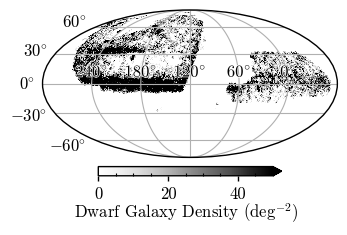

In [33]:
##let us compute the target sample specific target densities

density_map_64 = get_density_map(128, tot_cat["RA"].data, tot_cat["DEC"].data)

cmap = matplotlib.colormaps['Greys'].copy()
cmap.set_bad(color='white')

fontsize_dict = {"cbar_label":12, "cbar_tick_label":12}

ax = projview(
    density_map_64, min=0,max = 50,rot = (120, 0, 0), graticule=True, graticule_labels=True, projection_type="mollweide",
    nest=True,cmap = cmap,
    rot_graticule=False,width = 3.25,
    custom_xtick_labels=[r"$240^{\circ}$",r"$180^{\circ}$",r"$120^{\circ}$", r"$60^{\circ}$",r"$0^{\circ}$"],
    unit=r"Dwarf Galaxy Density (deg$^{-2}$)",cbar_ticks=[0,20,40],
    fontsize=fontsize_dict
)

##adding the rectangle 

# Define rectangle corners in RA/Dec
ra1, ra2 = 130 + 120, 230 + 120  # degrees
dec1, dec2 = -5, 5  # degrees

# Convert RA from [0,360] -> [-180,180] and then to radians
def ra_to_mollweide_radians(ra_deg):
    ra_wrapped = ((ra_deg + 180) % 360) - 180  # wrap into [-180, 180]
    return np.deg2rad(ra_wrapped)

# Convert Dec to radians directly
def dec_to_radians(dec_deg):
    return np.deg2rad(dec_deg)

# Get rectangle edges
ra_edges = [ra1, ra2, ra2, ra1, ra1]
dec_edges = [dec1, dec1, dec2, dec2, dec1]

x = ra_to_mollweide_radians(np.array(ra_edges))
y = dec_to_radians(np.array(dec_edges))

# Plot on the current axes (projview uses gca)
ax = plt.gca()
# ax.plot(x, y, color='r', lw=1,ls = "--",alpha=0.75)

yref = -20
shift = 12

import matplotlib.patheffects as pe

# Outline RA tick labels
for label in ax.get_xticklabels():
    label.set_color("black")
    label.set_path_effects([
        pe.Stroke(linewidth=1, foreground="white"),
        pe.Normal()
    ])


#######

ax.tick_params(
    axis="both",
    which="major",
)

# ax.set_title(r"DESI DR1 Dwarfs")

ax.set_yticklabels([fr'${int(r)}\!^\circ$' for r in [-60,-30,0,30,60]])

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/dwarf_galaxy_density.pdf")

plt.show()


### let us make another plot here of horizontal redshift slice, with massive galaxies on it?

In [38]:
bgsb_cat = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_bgs_bright_filter_zsucc_zrr02_allfracflux_INT.fits")

Task was destroyed but it is pending!
task: <Task pending name='Task-278' coro=<_async_in_context.<locals>.run_in_context() done, defined at /global/common/software/desi/perlmutter/desiconda/20260227-2.3.1/conda/lib/python3.13/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-279' coro=<Kernel.shell_main() running at /global/common/software/desi/perlmutter/desiconda/20260227-2.3.1/conda/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /global/common/software/desi/perlmutter/desiconda/20260227-2.3.1/conda/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py:563]>
/global/common/software/desi/perlmutter/desiconda/20260227-2.3.1/conda/lib/python3.13/site-packages/astropy/extern/configobj/configobj.py:550: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  def __getitem__(self, key):
Task was destroyed but it is pending!
task: <Task pending name='Task-279' coro=<Ker

In [39]:
bgsb_cat_f = bgsb_cat[ (bgsb_cat["FRACFLUX_R"] < 0.35) &  (bgsb_cat["FRACFLUX_Z"] < 0.35) &  (bgsb_cat["FRACFLUX_G"] < 0.35) & (bgsb_cat["Z"] < 0.2) & (bgsb_cat["DELTACHI2"] > 40) ]


In [42]:
from astropy.cosmology import Planck18

bgsb_cat_absmag_r = bgsb_cat_f["MAG_R"].data + 5 - 5*np.log10(Planck18.luminosity_distance(bgsb_cat_f["Z"].data).value * 1e6)

In [43]:
bgsb_cat_massive_mw = bgsb_cat_f[ (bgsb_cat_absmag_r < -21.5) & (bgsb_cat_f["Z"] < 0.1) & (bgsb_cat_f["Z"] > 0.001) ]["RA","DEC","Z"]


In [50]:
## for plotting we restrict to a small region
loc_mask = ( (bgsb_cat_massive_mw["RA"] < 230) & (bgsb_cat_massive_mw["RA"] > 130) & (bgsb_cat_massive_mw["DEC"] > -2.5) & (bgsb_cat_massive_mw["DEC"] < 2.5))

bgsb_cat_massive_mw_plot = bgsb_cat_massive_mw[loc_mask]

In [152]:
slice_mask = (tot_cat["SAMPLE"] != "ELG") & (tot_cat["SAMPLE"] != "OTHER") & (tot_cat["RA"] < 360) & (tot_cat["RA"] > 0) & (tot_cat["DEC"] > -5) & (tot_cat["DEC"] < 5) #& (tot_cat["Z"] < 0.2) 

tot_cat_slice_f = tot_cat[slice_mask]

In [153]:
#also read in the nsa catalog
nsa_cat = Table.read("/pscratch/sd/v/virajvm/catalog/nsa_v1_0_1.fits")

In [154]:
nsa_cat_mass_mask = (nsa_cat["SERSIC_MASS"]/0.7**2 > 1e11) & (nsa_cat["RA"] < 360) & (nsa_cat["RA"]> 0) & (nsa_cat["DEC"]< 5) & (nsa_cat["DEC"]> -5) & (nsa_cat["IN_DR7_LSS"] == 1)


In [157]:
## MAYBE GOOD TO DO IS_ELG, IS_BGS flag etc .. 

In [326]:
import numpy as np, matplotlib as mpl, matplotlib.pyplot as plt
import cmasher as cmr
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.transforms import ScaledTranslation
from matplotlib.offsetbox import TextArea, HPacker, AnnotationBbox
# WARM = LinearSegmentedColormap.from_list("warm_glow",
#         ["#7a1416","#c0241c","#ef5022","#ff861f","#ffbe3c","#ffe784"])
WARM = cmr.cosmic_r
CYAN = "r" # "#46e6ff"
def plot_dwarf_bowtie(dw_ra, dw_z, dw_logm, ma_ra, ma_z, zmax,
                      z_ticks=(0.02,0.04,0.06,0.08,0.10),
                      z_spoke=270, vmin=7, vmax=9, outfile=None):
    """RA (deg) vs redshift bowtie. dw_* = dwarfs colored by logM*,
    ma_* = NSA massive as cyan beads. z_spoke is the redshift-axis angle
    (270 deg = pointing right in the S-origin / clockwise frame)."""
    fig = plt.figure(figsize=(6.75,6.75), facecolor="white")
    ax = fig.add_axes([0.04,0.05,0.92,0.82], projection="polar", facecolor="white")
    ax.set_theta_zero_location("S")  # 0 deg at the bottom (South)
    ax.set_theta_direction(-1)       # clockwise RA -> left wedge points up
    ax.scatter(np.deg2rad(dw_ra), dw_z, c=dw_logm, cmap=WARM, norm=Normalize(vmin,vmax),
               s=1.5, alpha=1, lw=0, edgecolors="none", rasterized=True, zorder=2)
    
    if ma_ra is not None:
        ax.scatter(np.deg2rad(ma_ra), ma_z, color=CYAN, s=1.5, alpha=0.85, rasterized=True, zorder=4)  # bead core
        
    ax.set_rlim(0, zmax); ax.set_rorigin(0)
    ra_grid = np.arange(0,360,30)
    ax.set_xticks(np.deg2rad(ra_grid))
    ax.set_xticklabels([fr"${r}^{{\circ}}$" for r in ra_grid], color="black")
    ax.tick_params(axis="x", pad=2)
    
    # native radial (redshift) tick labels at z_spoke, in the usual offset position
    
    ax.set_rgrids(z_ticks, labels=[f"{z:.2f}" for z in z_ticks], angle=z_spoke)
    ax.tick_params(axis="y", colors="black")
    ax.grid(color="0.5", ls=":", lw=0.5, alpha=0.28)
    
    ax.spines["polar"].set_color("k"); ax.spines["polar"].set_linewidth(1)
    
    # extra padding for right-hand-side RA tick labels only (left side untouched).
    # screen angle phi: East = 0, CCW+ ; here phi(deg) = 270 - RA  (S-origin, clockwise frame)
    pad_pts = 4
    for ang, lab in zip(ra_grid, ax.get_xticklabels()):
        phi = np.deg2rad((270 - ang) % 360)
        if np.cos(phi) > 0.2:                                 # right-hand side
            lab.set_transform(lab.get_transform()
                              + ScaledTranslation(pad_pts/72*np.cos(phi),
                                                  pad_pts/72*np.sin(phi),
                                                  fig.dpi_scale_trans))
            
    # horizontal redshift axis line pointing right (z_spoke = 270 deg = East here)
    ax.plot([np.deg2rad(z_spoke)]*2, [0, zmax], color="k", lw=1.0, zorder=5)
    
    # Cartesian-style tick marks: "|" markers are vertical on screen, i.e. perpendicular
    # to the horizontal right-pointing axis. (Assumes z_spoke is left/right horizontal.)
    ax.plot(np.deg2rad([z_spoke]*len(z_ticks)), z_ticks, ls="none", marker="|",
            ms=5, mew=1, color="black", zorder=6, clip_on=False)
    ax.text(np.deg2rad(z_spoke+7.5), 0.04, "Redshift", color="black",
            ha="center", va="center", zorder=6, clip_on=False)
    
    sm = mpl.cm.ScalarMappable(norm=Normalize(vmin,vmax), cmap=WARM)
    cax = fig.add_axes([0.14,0.485,0.22,0.020])
    cb = fig.colorbar(sm, cax=cax, orientation="horizontal")
    cb.set_label(r"$\log_{10}(M_{\bigstar})$", color="black", labelpad=-2)

    # Two-color bold title, centered on the figure (no usetex needed -- pure mathtext
    # via offsetbox, so it works on NERSC without a LaTeX install).
    segs = [TextArea(r"DESI DR1 Dwarf Galaxies",     textprops=dict(color="black", weight="bold", size=12)),
            TextArea("and",                          textprops=dict(color="black",                size=12)),
            TextArea("SDSS/NSA Massive Galaxies",    textprops=dict(color="red",   weight="bold", size=12)),
            TextArea(r"($M_{\bigstar} \gtrsim 10^{11} \! M_{\odot}$)", textprops=dict(color="red",            size=12))]
    title = HPacker(children=segs, align="center", pad=0, sep=5)
    fig.add_artist(AnnotationBbox(title, (0.5, 0.94), xycoords="figure fraction",
                                  box_alignment=(0.5, 1.0), frameon=False, pad=0))


    if outfile: fig.savefig(outfile, dpi=300, facecolor="white")
    return fig, ax

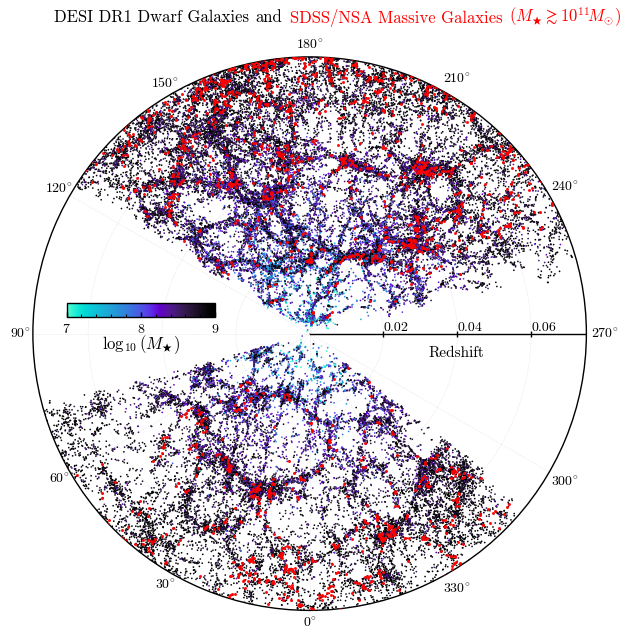

In [306]:

fig, ax = plot_dwarf_bowtie(
    tot_cat_slice_f["RA"],  tot_cat_slice_f["Z"],  tot_cat_slice_f["LOG_MSTAR_M24"],
    nsa_cat[nsa_cat_mass_mask]["RA"], nsa_cat[nsa_cat_mass_mask]["Z"],
    0.075, z_ticks=(0.02,0.04, 0.06), 
    outfile="/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/dwarf_galaxy_bowtie.pdf")

plt.show()

# Make a plot of number density of dwarf galaxies as a function of redshift?

For comparison, make some stellar mass function estimate?

In [7]:
from consolidate_photometry import load_clean_dwarf_catalog

In [8]:
main_cat = load_clean_dwarf_catalog()

load_clean_dwarf_catalog
  File: /pscratch/sd/v/virajvm/desi_dwarf_catalogs/dr1/v1.0/desi_dr1_dwarf_catalog.fits
  HDU:  MAIN
  Galaxies before filter (DWARF_MASKBIT == 0): 461488
  Galaxies after  filter (DWARF_MASKBIT == 0): 431791 (29697 dropped)


In [62]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u

# ---- cosmology ----
cosmo = Planck18

# ---- helper: solid angle of an RA/Dec box (steradians) ----
def box_solid_angle(ra_lo, ra_hi, dec_lo, dec_hi):
    return np.deg2rad(ra_hi - ra_lo) * (np.sin(np.deg2rad(dec_hi)) - np.sin(np.deg2rad(dec_lo)))

def sr_to_sqdeg(sr):
    return sr * (180.0 / np.pi)**2

# ---- DESI / SDSS comparison footprint ----
ra_lo, ra_hi = 130.0, 230.0
dec_lo, dec_hi = -5.0, 5.0
omega_desi = box_solid_angle(ra_lo, ra_hi, dec_lo, dec_hi)
fsky_desi  = omega_desi / (4 * np.pi)
print(f"DESI/SDSS footprint: {sr_to_sqdeg(omega_desi):.1f} deg^2")

# ---- GAMA equatorial fields (GAMA-II, 60 deg^2 each) ----
gama_fields = {
    "G09": (129.0, 141.0, -2.0,  3.0),
    "G12": (174.0, 186.0, -3.0,  2.0),
    "G15": (211.5, 223.5, -2.0,  3.0),
}
omega_gama = sum(box_solid_angle(*b) for b in gama_fields.values())
fsky_gama  = omega_gama / (4 * np.pi)
print(f"GAMA footprint:      {sr_to_sqdeg(omega_gama):.1f} deg^2")

def in_gama_equatorial(ra, dec, fields=gama_fields):
    ra = np.asarray(ra); dec = np.asarray(dec)
    m = np.zeros(len(ra), dtype=bool)
    for (ra_lo, ra_hi, dec_lo, dec_hi) in fields.values():
        m |= (ra >= ra_lo) & (ra <= ra_hi) & (dec >= dec_lo) & (dec <= dec_hi)
    return m

# ---- shell volume via astropy ----
def shell_volume(z_lo, z_hi, fsky, cosmo):
    V_lo = cosmo.comoving_volume(z_lo).to(u.Mpc**3).value
    V_hi = cosmo.comoving_volume(z_hi).to(u.Mpc**3).value
    return fsky * (V_hi - V_lo)  # Mpc^3

# ---- redshift bins ----
z_edges   = np.arange(0.001, 0.15, 0.005)
z_centers = 0.5 * (z_edges[1:] + z_edges[:-1])

vol_desi = np.array([shell_volume(z_edges[i], z_edges[i+1], fsky_desi, cosmo)
                     for i in range(len(z_edges)-1)])
vol_gama = np.array([shell_volume(z_edges[i], z_edges[i+1], fsky_gama, cosmo)
                     for i in range(len(z_edges)-1)])



DESI/SDSS footprint: 998.7 deg^2
GAMA footprint:      179.9 deg^2


In [63]:
# ---- n(z) helper ----
def n_of_z(cat, z_edges, vol_bins, zcol="Z"):
    z = np.asarray(cat[zcol])
    counts, _ = np.histogram(z, bins=z_edges)
    n = counts / vol_bins
    return counts, n


In [64]:


# ---- DESI selection ----
comp_reg_mask = ((main_cat["RA"]  < 230) & (main_cat["RA"]  > 130) &
                 (main_cat["DEC"] >  -5) & (main_cat["DEC"] <   5))
main_cat_bgsb = main_cat[(main_cat["SAMPLE"] != "ELG") & (main_cat["SAMPLE"] != "OTHER") &
                         comp_reg_mask &
                         (main_cat["DWARF_PRIMARY"] == True)]

main_cat_bgsb_7 = main_cat_bgsb[(main_cat_bgsb["LOG_MSTAR_M24"] > 6.75) & (main_cat_bgsb["LOG_MSTAR_M24"] < 7.25)]
main_cat_bgsb_8 = main_cat_bgsb[(main_cat_bgsb["LOG_MSTAR_M24"] > 7.75) & (main_cat_bgsb["LOG_MSTAR_M24"] < 8.25)]
main_cat_bgsb_9 = main_cat_bgsb[(main_cat_bgsb["LOG_MSTAR_M24"] > 8.75) & (main_cat_bgsb["LOG_MSTAR_M24"] < 9.25)]

# ---- SDSS selection (apply the SAME footprint cut so vol_desi is correct) ----
sdss_box = ((tot_cat_slice_sdss["RA"]  < 230) & (tot_cat_slice_sdss["RA"]  > 130) &
            (tot_cat_slice_sdss["DEC"] >  -5) & (tot_cat_slice_sdss["DEC"] <   5))
sdss_in = tot_cat_slice_sdss[sdss_box]
sdss_cat_7 = sdss_in[(sdss_in["MSTAR"] > 6.75) & (sdss_in["MSTAR"] < 7.25)]
sdss_cat_8 = sdss_in[(sdss_in["MSTAR"] > 7.75) & (sdss_in["MSTAR"] < 8.25)]
sdss_cat_9 = sdss_in[(sdss_in["MSTAR"] > 8.75) & (sdss_in["MSTAR"] < 9.25)]

# ---- GAMA selection (apply GAMA equatorial mask) ----
gama_in_mask = in_gama_equatorial(tot_cat_slice_gama["RA"], tot_cat_slice_gama["DEC"])
gama_in = tot_cat_slice_gama[gama_in_mask]
gama_7 = gama_in[(gama_in["MSTAR"] > 6.75) & (gama_in["MSTAR"] < 7.25)]
gama_8 = gama_in[(gama_in["MSTAR"] > 7.75) & (gama_in["MSTAR"] < 8.25)]
gama_9 = gama_in[(gama_in["MSTAR"] > 8.75) & (gama_in["MSTAR"] < 9.25)]

# ---- sample dicts (one entry per mass bin per survey) ----
mass_labels = [r"$\log M_\star \sim 7$", r"$\log M_\star \sim 8$", r"$\log M_\star \sim 9$"]
colors      = ["C1", "C2", "C3"]

desi_samples = dict(zip(mass_labels, zip([main_cat_bgsb_7, main_cat_bgsb_8, main_cat_bgsb_9], colors)))
sdss_samples = dict(zip(mass_labels, zip([sdss_cat_7,      sdss_cat_8,      sdss_cat_9     ], colors)))
gama_samples = dict(zip(mass_labels, zip([gama_7,          gama_8,          gama_9         ], colors)))



In [65]:
# ---- DESI selection ----
comp_reg_mask = ((main_cat["RA"]  < 230) & (main_cat["RA"]  > 130) &
                 (main_cat["DEC"] >  -5) & (main_cat["DEC"] <   5))
main_cat_elg = main_cat[(main_cat["SAMPLE"] == "ELG") & (main_cat["MAG_TYPE"] == "TRACTOR_OG") &
                         comp_reg_mask &
                         (main_cat["DWARF_PRIMARY"] == True)]

main_cat_elg_7 = main_cat_elg[(main_cat_elg["LOG_MSTAR_M24"] > 6.75) & (main_cat_elg["LOG_MSTAR_M24"] < 7.25)]
main_cat_elg_8 = main_cat_elg[(main_cat_elg["LOG_MSTAR_M24"] > 7.75) & (main_cat_elg["LOG_MSTAR_M24"] < 8.25)]
main_cat_elg_9 = main_cat_elg[(main_cat_elg["LOG_MSTAR_M24"] > 8.75) & (main_cat_elg["LOG_MSTAR_M24"] < 9.25)]

desi_elg_samples = dict(zip(mass_labels, zip([main_cat_elg_7, main_cat_elg_8, main_cat_elg_9], colors)))


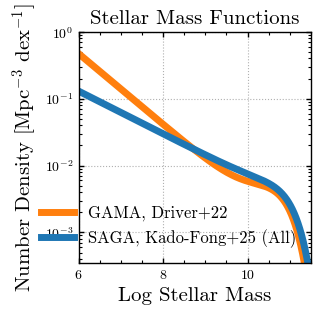

In [66]:
## SMF definitions + n(z) prediction helpers now live in
## code/plots/smf_nz_predictions.py (shared with elg_property_explore.ipynb).
from astropy import units as u
from scipy.integrate import quad

sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code/plots'))
from smf_nz_predictions import (
    gama_smf, load_sagabg_posterior, sagabg_smf,
    get_mstar_gr, get_logM_min_observable, predict_nz_in_mass_bin,
    build_inverse_cdf, build_intrinsic_catalog, nz_from_intrinsic,
    Mr_from_logM_gr, total_density_in_bin, total_density_band,
    plot_total_density_band,
)

# SAGAbg SMF percentile table (Kado-Fong+2025), "all" environment by default.
posterior = load_sagabg_posterior()

# Grey-band prediction shown in the n(z) figure:
#   "saga_posterior" -> nested inner 68% (16-84) + outer 90% (5-95) from SAGAbg
#   "saga_vs_gama"   -> range between the SAGAbg median and GAMA (Driver+22)
BAND_MODE = "saga_vs_gama"

# ---- reference SMF plot: SAGAbg median + 16-84 / 5-95 bands vs GAMA ----
mstar_vals = np.linspace(6, 11.5, 500)

plt.figure(figsize=(3, 3))
# Outer 5-95 then inner 16-84 percentile bands.
plt.fill_between(mstar_vals,
                 sagabg_smf(mstar_vals, posterior, "p5"),
                 sagabg_smf(mstar_vals, posterior, "p95"),
                 color="tab:blue", alpha=0.1)
plt.fill_between(mstar_vals,
                 sagabg_smf(mstar_vals, posterior, "p16"),
                 sagabg_smf(mstar_vals, posterior, "p84"),
                 color="tab:blue", alpha=0.2)
plt.plot(mstar_vals, sagabg_smf(mstar_vals, posterior, "central"),
         lw=2, color="tab:blue", label="SAGAbg (all)")
plt.plot(mstar_vals, gama_smf(mstar_vals),
         lw=2, color="tab:orange", label="GAMA (Driver+22)")

plt.title("Stellar Mass Functions", fontsize=15)
plt.yscale("log")
plt.ylabel("Number Density [Mpc$^{-3}$ dex$^{-1}$]", fontsize=12)
plt.xlabel(r"$\log_{10}(M_\star/M_\odot)$", fontsize=12)
plt.ylim([3.5e-4, 2.0])
plt.xlim([6, 11.5])
plt.legend(frameon=False, fontsize=11)
plt.grid(ls=":")
plt.show()


In [75]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
from scipy.optimize import brentq

# Redshift grid: match the data n(z) plot exactly
z_edges   = np.arange(0.001, 0.15, 0.005)
z_centers = 0.5 * (z_edges[1:] + z_edges[:-1])
n_zbins   = len(z_centers)

# Stellar-mass bins (width 0.5 dex, centers at 7, 8, 9)
mass_bins = {
    r"$\log M_\star \sim 7$": (6.75, 7.25),
    r"$\log M_\star \sim 8$": (7.75, 8.25),
    r"$\log M_\star \sim 9$": (8.75, 9.25),
}

# r-band magnitude limits
rmag_limits = {
    "Volume-limited":             None,
    "SDSS (r<17.7)":              17.7,
    "DESI BGS Bright (r<19.5)":   19.5,
    "DESI BGS+LOWZ (r<21.15)":    21.15,
}

# get_mstar_gr, get_logM_min_observable, predict_nz_in_mass_bin and the mock-catalog
# helpers are imported from smf_nz_predictions (see cell above).

In [76]:
# get_logM_min_observable imported from smf_nz_predictions

In [77]:
# At z=0.05 with r<19.5, what's the minimum observable mass?
z_test = 0.05
for rlim in [17.7, 19.5, 21.15]:
    logM_min = get_logM_min_observable(z_test, rlim)
    print(f"r<{rlim}: logM_min = {logM_min:.2f}, "
          f"gr at that mass = {get_mstar_gr(logM_min):.2f}")

r<17.7: logM_min = 9.40, gr at that mass = 0.46
r<19.5: logM_min = 8.68, gr at that mass = 0.40
r<21.15: logM_min = 8.02, gr at that mass = 0.34


In [78]:
# predict_nz_in_mass_bin imported from smf_nz_predictions

In [79]:
smfs = {
    "GAMA (Driver+22)": gama_smf,
    "SAGAbg (KF+25)":   posterior["central"],
}

# results[smf_name][rmag_label][mass_label] -> array of n(z)
results = {}
for smf_name, smf_fn in smfs.items():
    results[smf_name] = {}
    for rmag_label, rmag_lim in rmag_limits.items():
        results[smf_name][rmag_label] = {}
        for mass_label, (lo, hi) in mass_bins.items():
            results[smf_name][rmag_label][mass_label] = predict_nz_in_mass_bin(
                smf_fn, z_edges, lo, hi, rmag_limit=rmag_lim
            )

# Quick check at z=0.02
print("n(z=0.02) [Mpc^-3], GAMA SMF:")
iz = np.argmin(np.abs(z_centers - 0.01))
for rmag_label in rmag_limits:
    row = " | ".join(f"{m}: {results['GAMA (Driver+22)'][rmag_label][m][iz]:.2e}"
                     for m in mass_bins)
    print(f"  {rmag_label:30s} | {row}")

n(z=0.02) [Mpc^-3], GAMA SMF:
  Volume-limited                 | $\log M_\star \sim 7$: 7.11e-02 | $\log M_\star \sim 8$: 2.11e-02 | $\log M_\star \sim 9$: 6.57e-03
  SDSS (r<17.7)                  | $\log M_\star \sim 7$: 0.00e+00 | $\log M_\star \sim 8$: 1.65e-02 | $\log M_\star \sim 9$: 6.57e-03
  DESI BGS Bright (r<19.5)       | $\log M_\star \sim 7$: 1.49e-02 | $\log M_\star \sim 8$: 2.11e-02 | $\log M_\star \sim 9$: 6.57e-03
  DESI BGS+LOWZ (r<21.15)        | $\log M_\star \sim 7$: 7.11e-02 | $\log M_\star \sim 8$: 2.11e-02 | $\log M_\star \sim 9$: 6.57e-03


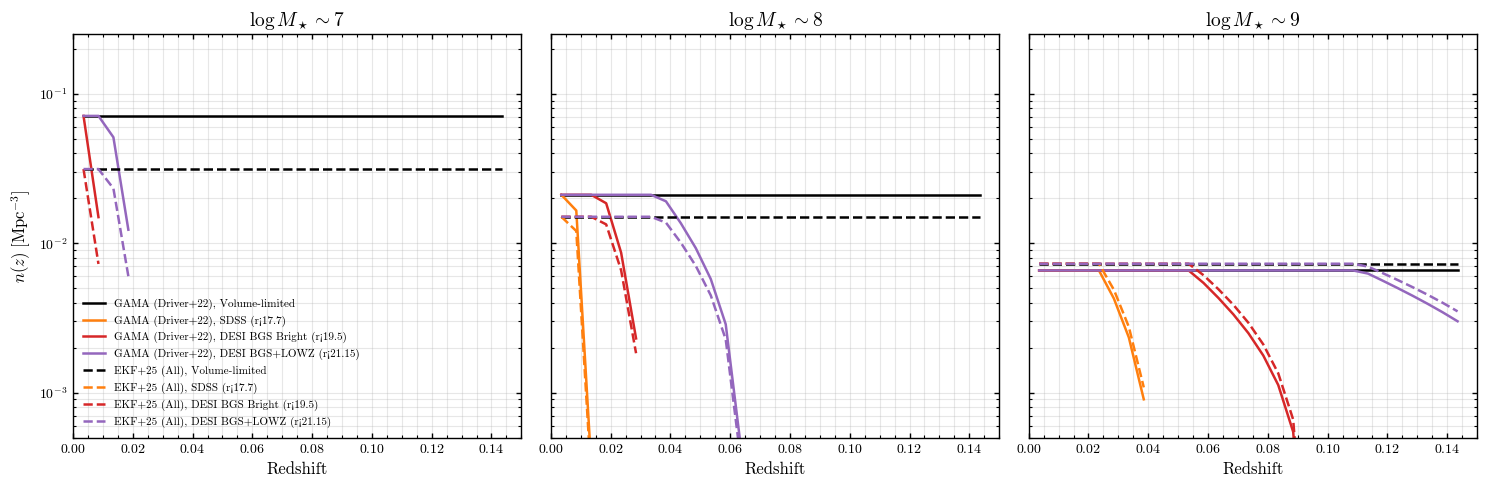

In [83]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

rmag_colors = {
    "Volume-limited":             "k",
    "SDSS (r<17.7)":              "tab:orange",
    "DESI BGS Bright (r<19.5)":   "tab:red",
    "DESI BGS+LOWZ (r<21.15)":    "tab:purple",
}
smf_ls = {
    "GAMA (Driver+22)": "-",
    "SAGAbg (KF+25)":   "--",
}

for i, (mass_label, (lo, hi)) in enumerate(mass_bins.items()):
    ax = axes[i]
    for smf_name, ls in smf_ls.items():
        for rmag_label, color in rmag_colors.items():
            nz = results[smf_name][rmag_label][mass_label]
            m = nz > 0
            if not m.any():
                continue
            label = f"{smf_name}, {rmag_label}" if i == 0 else None
            ax.plot(z_centers[m], nz[m], ls=ls, color=color, lw=1.8, label=label)

    ax.set_yscale("log")
    ax.set_xlim(0, 0.15)
    ax.set_ylim(5e-4, 2.5e-1)
    ax.set_xlabel("Redshift")
    ax.set_title(mass_label, fontsize=14)
    ax.grid(alpha=0.3, which="both")

axes[0].set_ylabel(r"$n(z)\ [\mathrm{Mpc}^{-3}]$")
axes[0].legend(frameon=False, fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

In [84]:
# build_inverse_cdf / Mr_from_logM_gr imported from smf_nz_predictions.
# Inverse-CDF samplers for the mock-catalog path.
gama_inv_cdf, gama_density = build_inverse_cdf(gama_smf)
saga_inv_cdf, saga_density = build_inverse_cdf(posterior["central"])

In [86]:
# build_intrinsic_catalog imported from smf_nz_predictions.
mock_gama = build_intrinsic_catalog(gama_inv_cdf)
mock_saga = build_intrinsic_catalog(saga_inv_cdf)

In [87]:
# nz_from_intrinsic imported from smf_nz_predictions.
# mock_results[smf_name][rmag_label][mass_label] -> array of n(z)
mock_results = {}
mocks = {"GAMA (Driver+22)": (mock_gama, gama_density),
         "SAGAbg (KF+25)":   (mock_saga, saga_density)}

for smf_name, (cat, density) in mocks.items():
    mock_results[smf_name] = {}
    for rmag_label, rmag_lim in rmag_limits.items():
        mock_results[smf_name][rmag_label] = {}
        for mass_label, (lo, hi) in mass_bins.items():
            mock_results[smf_name][rmag_label][mass_label] = nz_from_intrinsic(
                cat, density, z_centers, lo, hi, rmag_limit=rmag_lim
            )

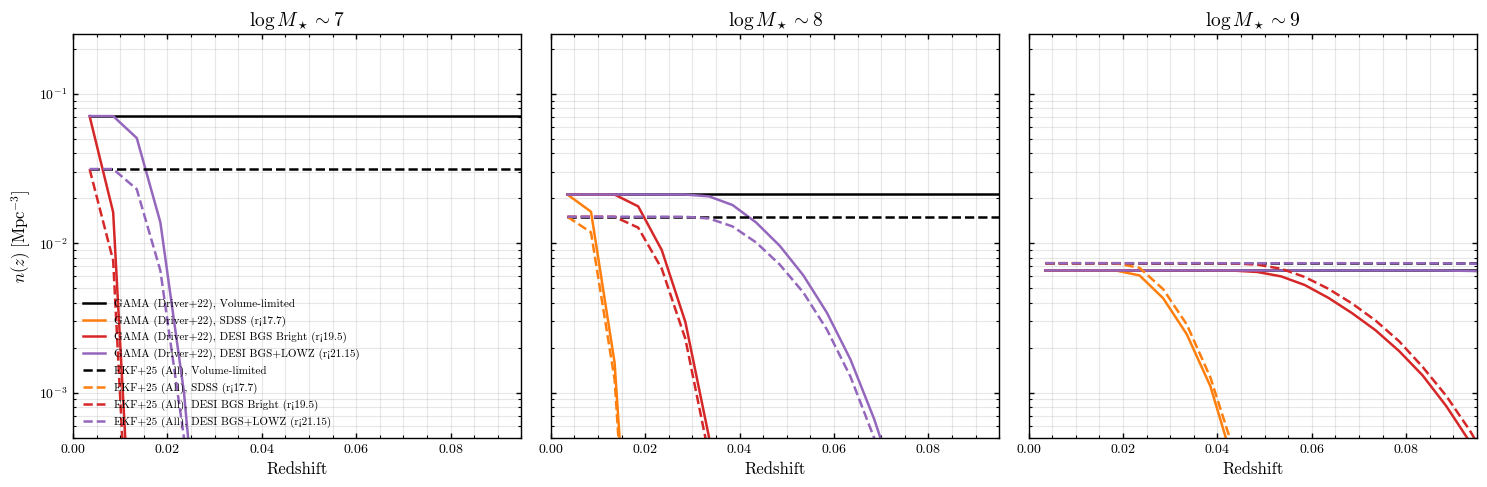

In [88]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

rmag_colors = {
    "Volume-limited":             "k",
    "SDSS (r<17.7)":              "tab:orange",
    "DESI BGS Bright (r<19.5)":   "tab:red",
    "DESI BGS+LOWZ (r<21.15)":    "tab:purple",
}
smf_ls = {"GAMA (Driver+22)": "-", "SAGAbg (KF+25)": "--"}

for i, (mass_label, _) in enumerate(mass_bins.items()):
    ax = axes[i]
    for smf_name, ls in smf_ls.items():
        for rmag_label, color in rmag_colors.items():
            nz = mock_results[smf_name][rmag_label][mass_label]
            m = nz > 0
            if not m.any():
                continue
            label = f"{smf_name}, {rmag_label}" if i == 0 else None
            ax.plot(z_centers[m], nz[m], ls=ls, color=color, lw=1.8, label=label)

    ax.set_yscale("log")
    ax.set_xlim(0, 0.095)
    ax.set_ylim(5e-4, 2.5e-1)
    ax.set_xlabel("Redshift")
    ax.set_title(mass_label, fontsize=14)
    ax.grid(alpha=0.3, which="both")

axes[0].set_ylabel(r"$n(z)\ [\mathrm{Mpc}^{-3}]$")
axes[0].legend(frameon=False, fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

In [89]:
rmag_ls = {
    "Volume-limited":             "k",
    "SDSS (r<17.7)":              "dotted",
    "DESI BGS Bright (r<19.5)":   "-.",
    "DESI BGS+LOWZ (r<21.15)":    "--",
}

rmag_labels = {
    "Volume-limited":             None,
    "SDSS (r<17.7)":              r"$r < 17.7$",
    "DESI BGS Bright (r<19.5)":    r"$r < 19.5$",
    "DESI BGS+LOWZ (r<21.15)":     r"$r < 21.15$",
}


In [99]:
## maybe best to pick erin's smf's here??

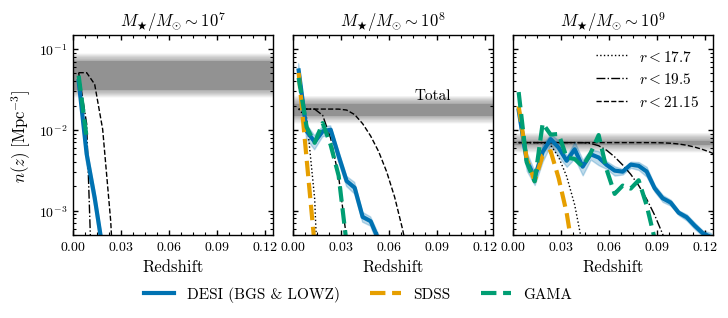

In [110]:
fig, ax = make_subplots(ncol=3, nrow=1, plot_size=2,return_fig=True,
                       col_spacing=[MARGIN_LABEL, MARGIN_SHARED+0.1, MARGIN_SHARED+0.1, MARGIN_PAD],
                       row_spacing=[MARGIN_LABEL, MARGIN_PAD])


for i, (mass_label, (lo_m, hi_m)) in enumerate(mass_bins.items()):
    for rmag_label, ls in rmag_ls.items():
        if i == 2:
            leg_label = rmag_labels[rmag_label]
        else:
            leg_label = None

        if rmag_label == "Volume-limited":
            # Expected total-density band (volume-limited) for this mass bin.
            # BAND_MODE selects nested SAGAbg percentiles or the SAGAbg-vs-GAMA range.
            plot_total_density_band(
                ax[i], (0, 0.125), lo_m, hi_m, BAND_MODE, posterior,
                color="k", label=leg_label,
            )
        else:
            # Magnitude-limited prediction: average of SAGAbg & GAMA mock catalogs.
            nz_saga = mock_results['SAGAbg (KF+25)'][rmag_label][mass_label]
            nz_gama = mock_results['GAMA (Driver+22)'][rmag_label][mass_label]
            nz_ave = 0.5 * (nz_saga + nz_gama)

            m = nz_ave > 0
            if not m.any():
                continue

            ax[i].plot(z_centers[m], nz_ave[m], ls=ls, color='k', lw=1, label=leg_label)

ax[2].legend(frameon=False,loc="upper right",ncol=1)

for i, label in enumerate(mass_labels):
    # DESI
    cat, color = desi_samples[label]
    counts, n = n_of_z(cat, z_edges, vol_desi)

    m = counts > 0
    ax[i].plot(z_centers[m], n[m], ls="-",
                   color="#0072B2", label=fr"DESI (BGS & LOWZ)", lw = 3)


    ## DESI ELG
    #THE DESI ELG number density is much lower than 1e-3, so not shwon here
    # cat, color = desi_elg_samples[label]
    
    # counts, n = n_of_z(cat, z_edges, vol_desi)

    # ax[i].plot(z_centers[m], n[m], ls="-",
    #                color="cyan", label=fr"DESI (ELG)", lw = 3)
    
    # SDSS
    cat, color = sdss_samples[label]
    counts, n = n_of_z(cat, z_edges, vol_desi)  # same footprint as DESI

    m = counts > 0
    ax[i].plot(z_centers[m], n[m], ls="--", color="#E69F00", label=f"SDSS", lw = 3)

    # GAMA
    cat, color = gama_samples[label]
    counts, n = n_of_z(cat, z_edges, vol_gama)   # GAMA footprint
    m = counts > 0
    ax[i].plot(z_centers[m], n[m], ls = "--", color="#009E73", label=f"GAMA", lw = 3)

    ax[i].set_yscale("log")
    ax[0].set_ylabel(r"$n(z)\ [\mathrm {Mpc}^{-3}]$")
    ax[i].set_ylim(5e-4, 1.5e-1)
    ax[i].set_xlim([0,0.125])
    
    # ax[0].legend(frameon=False, loc="upper right",ncol=2)
    
    ax[1].set_yticklabels([])
    ax[2].set_yticklabels([])
    
    ax[i].set_xlabel("Redshift")

    ax[i].set_xticks([0,0.03,0.06,0.09,0.12])

# ax[0].set_title(r"$10^{6.75} < M_{\bigstar} / M_{\odot} < 10^{7.25}$")
# ax[1].set_title(r"$10^{7.75} < M_{\bigstar} / M_{\odot} < 10^{8.25}$")
# ax[2].set_title(r"$10^{8.75} < M_{\bigstar} / M_{\odot} < 10^{9.25}$")

ax[0].set_title(r"$M_{\bigstar} / M_{\odot} \sim 10^{7}$")
ax[1].set_title(r"$M_{\bigstar} / M_{\odot} \sim 10^{8}$")
ax[2].set_title(r"$M_{\bigstar} / M_{\odot} \sim 10^{9}$")

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="lower center",
           bbox_to_anchor=(0.5, 0.03),   # tweak the -0.05 to move it up/down
           ncol=3,
           frameon=False)

ax[1].text(0.7,0.7,"Total",color="k",transform=ax[1].transAxes,ha="center",va="center")

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/desi_dwarf_nz.pdf")

plt.show()

In [111]:
## make a rough plot as well!